In [1]:
from pathlib import Path

from hloc import (
    extract_features,
    match_features,
    pairs_from_retrieval,
    localize_sfm
)

from hloc.utils import viz_3d

In [2]:
print(localize_sfm)

<module 'hloc.localize_sfm' from 'E:\\Hierarchical-Localization-master\\hloc\\localize_sfm.py'>


In [3]:
from hloc import extract_features, match_features, pairs_from_retrieval
from hloc import localize_sfm

from pathlib import Path

In [4]:
dataset = Path("datasets/my_desk")

query = dataset / "query"

outputs = Path("outputs/my_desk_v2")


sfm_dir = outputs / "sfm"

features = outputs / "features_query.h5"

matches = outputs / "matches_query.h5"

loc_pairs = outputs / "pairs-query.txt"


print("query:", query)
print("sfm:", sfm_dir)

query: datasets\my_desk\query
sfm: outputs\my_desk_v2\sfm


In [5]:
feature_conf = extract_features.confs["aliked-n16"]


extract_features.main(
    feature_conf,
    query,
    feature_path=features
)

[2026/07/20 15:57:53 hloc INFO] Extracting local features with configuration:
{'model': {'model_name': 'aliked-n16', 'name': 'aliked'},
 'output': 'feats-aliked-n16',
 'preprocessing': {'grayscale': False, 'resize_max': 1024}}
[2026/07/20 15:57:53 hloc INFO] Found 8 images in root datasets\my_desk\query.
100%|██████████| 8/8 [00:05<00:00,  1.45it/s]
[2026/07/20 15:58:03 hloc INFO] Finished exporting features.


WindowsPath('outputs/my_desk_v2/features_query.h5')

In [8]:
import hloc
print(hloc.__file__)

E:\Hierarchical-Localization-master\hloc\__init__.py


In [9]:
import importlib.metadata

print(importlib.metadata.version("hloc"))

1.5


In [10]:
import inspect
from hloc import pairs_from_retrieval

print(inspect.signature(pairs_from_retrieval.main))

(descriptors, output, num_matched, query_prefix=None, query_list=None, db_prefix=None, db_list=None, db_model=None, db_descriptors=None)


In [11]:
from pathlib import Path

for p in Path("outputs/my_desk_v2").rglob("*"):
    print(p)

outputs\my_desk_v2\features.h5
outputs\my_desk_v2\features_query.h5
outputs\my_desk_v2\matches.h5
outputs\my_desk_v2\pairs-sfm.txt
outputs\my_desk_v2\sfm
outputs\my_desk_v2\sfm\cameras.bin
outputs\my_desk_v2\sfm\colmap.LOG.20260720-151649.36700
outputs\my_desk_v2\sfm\database.db
outputs\my_desk_v2\sfm\frames.bin
outputs\my_desk_v2\sfm\images.bin
outputs\my_desk_v2\sfm\models
outputs\my_desk_v2\sfm\points3D.bin
outputs\my_desk_v2\sfm\rigs.bin
outputs\my_desk_v2\sfm\models\0


In [12]:
from pathlib import Path

print(Path("outputs/my_desk_v2/features_query.h5").exists())

True


In [13]:
print(Path("outputs/my_desk_v2/retrieval.h5").exists())

False


In [15]:
from hloc import extract_features

In [16]:
extract_features.confs.keys()

dict_keys(['superpoint_aachen', 'superpoint_max', 'superpoint_inloc', 'r2d2', 'd2net-ss', 'sift', 'sosnet', 'disk', 'aliked-n16', 'dir', 'netvlad', 'openibl', 'megaloc'])

In [17]:
from pathlib import Path

mapping_dir = Path("datasets/my_desk/mapping")
query_dir = Path("datasets/my_desk/query")

outputs = Path("outputs/my_desk_v2")
sfm_dir = outputs / "sfm"

db_global = outputs / "global_mapping_netvlad.h5"
query_global = outputs / "global_query_netvlad.h5"
loc_pairs = outputs / "pairs-query.txt"

mapping_list = sorted(
    p.name for p in mapping_dir.iterdir()
    if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
)

query_list = sorted(
    p.name for p in query_dir.iterdir()
    if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
)

print("建图图片：", len(mapping_list))
print("查询图片：", len(query_list))
print("SfM模型存在：", sfm_dir.exists())

建图图片： 312
查询图片： 8
SfM模型存在： True


In [18]:
retrieval_conf = extract_features.confs["netvlad"]

extract_features.main(
    retrieval_conf,
    mapping_dir,
    image_list=mapping_list,
    feature_path=db_global
)

extract_features.main(
    retrieval_conf,
    query_dir,
    image_list=query_list,
    feature_path=query_global
)

print("地图全局特征：", db_global.exists())
print("查询全局特征：", query_global.exists())

[2026/07/20 16:09:18 hloc INFO] Extracting local features with configuration:
{'model': {'name': 'netvlad'},
 'output': 'global-feats-netvlad',
 'preprocessing': {'resize_max': 1024}}
100%|██████████| 529M/529M [04:56<00:00, 1.87MB/s] 
100%|██████████| 312/312 [00:31<00:00,  9.83it/s]
[2026/07/20 16:14:55 hloc INFO] Finished exporting features.
[2026/07/20 16:14:55 hloc INFO] Extracting local features with configuration:
{'model': {'name': 'netvlad'},
 'output': 'global-feats-netvlad',
 'preprocessing': {'resize_max': 1024}}
100%|██████████| 8/8 [00:04<00:00,  1.67it/s]
[2026/07/20 16:15:07 hloc INFO] Finished exporting features.


地图全局特征： True
查询全局特征： True


In [19]:
import h5py

with h5py.File(query_global, "r") as f:
    first_query = list(f.keys())[0]
    print("第一张查询图：", first_query)
    print("内部字段：", list(f[first_query].keys()))

with h5py.File(db_global, "r") as f:
    first_db = list(f.keys())[0]
    print("第一张地图图：", first_db)
    print("内部字段：", list(f[first_db].keys()))

第一张查询图： 001.jpg
内部字段： ['global_descriptor', 'image_size']
第一张地图图： 00000.jpg
内部字段： ['global_descriptor', 'image_size']


In [20]:
pairs_from_retrieval.main(
    descriptors=query_global,
    output=loc_pairs,
    num_matched=20,
    db_model=sfm_dir,
    db_descriptors=db_global
)

[2026/07/20 16:16:16 hloc INFO] Extracting image pairs from a retrieval database.
[2026/07/20 16:16:17 hloc INFO] Found 160 pairs.


In [21]:
print("检索文件存在：", loc_pairs.exists())

lines = loc_pairs.read_text(encoding="utf-8").splitlines()

print("检索对数量：", len(lines))
print("\n前20个检索结果：")

for line in lines[:20]:
    print(line)

检索文件存在： True
检索对数量： 160

前20个检索结果：
004.jpg 00197.jpg
004.jpg 00198.jpg
004.jpg 00199.jpg
004.jpg 00196.jpg
004.jpg 00123.jpg
004.jpg 00239.jpg
004.jpg 00201.jpg
004.jpg 00240.jpg
004.jpg 00124.jpg
004.jpg 00120.jpg
004.jpg 00158.jpg
004.jpg 00211.jpg
004.jpg 00037.jpg
004.jpg 00195.jpg
004.jpg 00041.jpg
004.jpg 00193.jpg
004.jpg 00159.jpg
004.jpg 00035.jpg
004.jpg 00203.jpg
004.jpg 00194.jpg


In [22]:
from pathlib import Path
from hloc import match_features

outputs = Path("outputs/my_desk_v2")

loc_pairs = outputs / "pairs-query.txt"

query_local_features = outputs / "features_query.h5"
mapping_local_features = outputs / "features.h5"

loc_matches = outputs / "matches-query-aliked-lightglue.h5"

matcher_conf = match_features.confs["aliked+lightglue"]

match_features.main(
    matcher_conf,
    loc_pairs,
    features=query_local_features,
    features_ref=mapping_local_features,
    matches=loc_matches,
    overwrite=False
)

print("匹配文件存在：", loc_matches.exists())
print("匹配文件路径：", loc_matches.resolve())

[2026/07/20 16:20:17 hloc INFO] Matching local features with configuration:
{'model': {'features': 'aliked', 'name': 'lightglue'},
 'output': 'matches-aliked-lightglue'}
100%|██████████| 160/160 [00:16<00:00,  9.49it/s]
[2026/07/20 16:20:34 hloc INFO] Finished exporting matches.


匹配文件存在： True
匹配文件路径： E:\Hierarchical-Localization-master\outputs\my_desk_v2\matches-query-aliked-lightglue.h5


In [23]:
from pathlib import Path
import pycolmap

query_dir = Path("datasets/my_desk/query")
queries_file = Path("outputs/my_desk_v2/queries_with_intrinsics.txt")

query_images = sorted(
    [
        p for p in query_dir.iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ]
)

with queries_file.open("w", encoding="utf-8") as f:
    for image_path in query_images:
        camera = pycolmap.infer_camera_from_image(str(image_path))

        params = " ".join(
            format(float(x), ".12g")
            for x in camera.params
        )

        f.write(
            f"{image_path.name} "
            f"{camera.model_name} "
            f"{camera.width} "
            f"{camera.height} "
            f"{params}\n"
        )

print("查询相机文件：", queries_file.resolve())
print("查询图数量：", len(query_images))
print()
print(queries_file.read_text(encoding="utf-8"))

查询相机文件： E:\Hierarchical-Localization-master\outputs\my_desk_v2\queries_with_intrinsics.txt
查询图数量： 8

001.jpg SIMPLE_RADIAL 5712 4284 6854.4 2856 2142 0
002.jpg SIMPLE_RADIAL 5712 4284 6854.4 2856 2142 0
003.jpg SIMPLE_RADIAL 5712 4284 6854.4 2856 2142 0
004.jpg SIMPLE_RADIAL 5712 4284 6854.4 2856 2142 0
005.jpg SIMPLE_RADIAL 5712 4284 6854.4 2856 2142 0
006.jpg SIMPLE_RADIAL 5712 4284 6854.4 2856 2142 0
007.jpg SIMPLE_RADIAL 5712 4284 6854.4 2856 2142 0
008.jpg SIMPLE_RADIAL 5712 4284 6854.4 2856 2142 0



In [24]:
from pathlib import Path
from hloc import localize_sfm

outputs = Path("outputs/my_desk_v2")

sfm_dir = outputs / "sfm"
queries_file = outputs / "queries_with_intrinsics.txt"
loc_pairs = outputs / "pairs-query.txt"
query_local_features = outputs / "features_query.h5"
loc_matches = outputs / "matches-query-aliked-lightglue.h5"

pose_results = outputs / "query_poses.txt"

localize_sfm.main(
    reference_sfm=sfm_dir,
    queries=queries_file,
    retrieval=loc_pairs,
    features=query_local_features,
    matches=loc_matches,
    results=pose_results,
    ransac_thresh=12,
    covisibility_clustering=False
)

print("位姿结果文件存在：", pose_results.exists())
print("位姿结果路径：", pose_results.resolve())

[2026/07/20 16:21:22 hloc.utils.parsers INFO] Imported 8 images from queries_with_intrinsics.txt
[2026/07/20 16:21:22 hloc INFO] Reading the 3D model...
[2026/07/20 16:21:22 hloc INFO] Starting localization...
100%|██████████| 8/8 [00:01<00:00,  5.95it/s]
[2026/07/20 16:21:23 hloc INFO] Localized 8 / 8 images.
[2026/07/20 16:21:23 hloc INFO] Writing poses to outputs\my_desk_v2\query_poses.txt...
[2026/07/20 16:21:23 hloc INFO] Writing logs to outputs\my_desk_v2\query_poses.txt_logs.pkl...
[2026/07/20 16:21:23 hloc INFO] Done!


位姿结果文件存在： True
位姿结果路径： E:\Hierarchical-Localization-master\outputs\my_desk_v2\query_poses.txt


In [25]:
import pickle
from pathlib import Path

pose_results = Path("outputs/my_desk_v2/query_poses.txt")
logs_file = Path(str(pose_results) + "_logs.pkl")

with logs_file.open("rb") as f:
    logs = pickle.load(f)

print("逐张定位质量：")
print("-" * 60)

success_count = 0

for query_name, info in logs["loc"].items():
    ret = info.get("PnP_ret")

    if ret is None:
        print(f"{query_name}: PnP失败，使用了参考图回退位姿")
        continue

    num_inliers = int(ret["num_inliers"])
    success_count += 1

    mask = ret.get("inlier_mask")
    total = len(mask) if mask is not None else 0

    ratio = num_inliers / total if total else 0

    print(
        f"{query_name}: 成功，"
        f"内点={num_inliers}/{total}，"
        f"内点率={ratio:.1%}"
    )

print("-" * 60)
print(f"真正PnP成功：{success_count}/8")

逐张定位质量：
------------------------------------------------------------
001.jpg: 成功，内点=5/46，内点率=10.9%
002.jpg: 成功，内点=5/111，内点率=4.5%
003.jpg: 成功，内点=12/229，内点率=5.2%
004.jpg: 成功，内点=6/227，内点率=2.6%
005.jpg: 成功，内点=29/402，内点率=7.2%
006.jpg: 成功，内点=6/138，内点率=4.3%
007.jpg: 成功，内点=5/69，内点率=7.2%
008.jpg: 成功，内点=7/146，内点率=4.8%
------------------------------------------------------------
真正PnP成功：8/8


In [26]:
from pathlib import Path

pose_results = Path("outputs/my_desk_v2/query_poses.txt")

print(pose_results.read_text(encoding="utf-8"))

001.jpg 0.37595387584373624 0.8576445156945187 -0.2480148499434976 -0.2481797778721927 3.7158249294689947 1.926510705603385 12.126643591753266
002.jpg 0.9251118848861498 -0.11306173343956996 0.20312522887423637 0.30020857127807604 -6.5730916741277605 -2.3816962426683173 6.4900427966597025
003.jpg 0.7839548914552991 0.18790399056762114 0.3037604976788851 -0.5077759137079563 -2.129747208462906 1.4821436795478906 5.504845603243074
004.jpg -0.04624510588156508 0.6669434153177489 0.581947492706699 0.46301726390998255 -1.192510122488842 -4.556106972637112 10.44576835465137
005.jpg 0.7449350971661101 0.07991638192248877 0.1857914012109022 -0.6357410071299688 0.2973395047677206 2.3883144737906927 9.856361821627434
006.jpg 0.8813338861927079 0.0793586386437671 0.2582902750982432 -0.3876066579804081 -2.6823704559248025 -3.4242661474016947 14.451316624070119
007.jpg 0.9340870839292176 -0.32942962891906424 0.05593594806457523 -0.1258117996889644 1.1842889877032106 -2.0700578599519344 -0.7317861135

In [27]:
import numpy as np
from pathlib import Path
from scipy.spatial.transform import Rotation

pose_results = Path("outputs/my_desk_v2/query_poses.txt")

camera_centers = {}

for line in pose_results.read_text(encoding="utf-8").splitlines():
    if not line.strip():
        continue

    values = line.split()

    name = values[0]

    qw, qx, qy, qz = map(float, values[1:5])
    tx, ty, tz = map(float, values[5:8])

    # SciPy四元数顺序为 x, y, z, w
    R_cam_from_world = Rotation.from_quat(
        [qx, qy, qz, qw]
    ).as_matrix()

    t_cam_from_world = np.array([tx, ty, tz])

    camera_center_world = (
        -R_cam_from_world.T @ t_cam_from_world
    )

    camera_centers[name] = camera_center_world

print("查询相机在COLMAP/HLoc世界坐标系中的位置：")
print("-" * 65)

for name in sorted(camera_centers):
    x, y, z = camera_centers[name]

    print(
        f"{name}: "
        f"X={x: .6f}, "
        f"Y={y: .6f}, "
        f"Z={z: .6f}"
    )

查询相机在COLMAP/HLoc世界坐标系中的位置：
-----------------------------------------------------------------
001.jpg: X= 1.279003, Y=-7.280661, Z= 10.484770
002.jpg: X= 8.939111, Y=-1.495326, Z=-2.975728
003.jpg: X= 5.321535, Y= 1.401876, Z=-2.598444
004.jpg: X=-3.798622, Y=-5.458800, Z= 9.330929
005.jpg: X= 5.884577, Y= 0.437109, Z=-8.253546
006.jpg: X= 6.787758, Y= 5.166933, Z=-12.449514
007.jpg: X=-1.718030, Y= 0.859852, Z= 1.591294
008.jpg: X= 12.901407, Y=-0.913757, Z=-5.615333


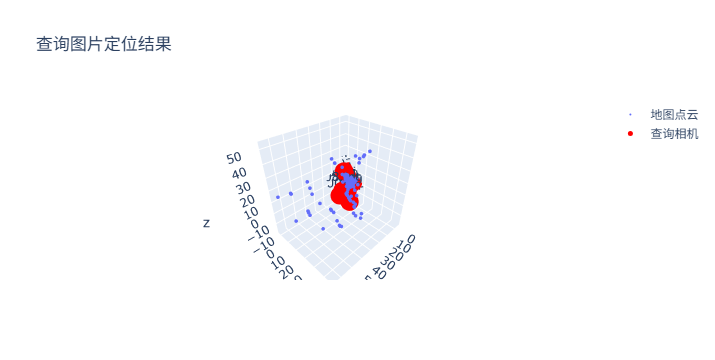

In [28]:
import numpy as np
import plotly.graph_objects as go
import pycolmap
from pathlib import Path

sfm_dir = Path("outputs/my_desk_v2/sfm")
model = pycolmap.Reconstruction(str(sfm_dir))

# 地图点云，最多显示3000点，避免浏览器卡顿
points = np.array([
    point.xyz
    for point in model.points3D.values()
])

if len(points) > 3000:
    ids = np.linspace(
        0,
        len(points) - 1,
        3000,
        dtype=int
    )
    points = points[ids]

query_names = sorted(camera_centers.keys())

query_xyz = np.array([
    camera_centers[name]
    for name in query_names
])

fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=points[:, 0],
        y=points[:, 1],
        z=points[:, 2],
        mode="markers",
        marker={"size": 1},
        name="地图点云"
    )
)

fig.add_trace(
    go.Scatter3d(
        x=query_xyz[:, 0],
        y=query_xyz[:, 1],
        z=query_xyz[:, 2],
        mode="markers+text",
        marker={
            "size": 5,
            "color": "red"   # 改成红色
        },
        text=query_names,
        textposition="top center",
        name="查询相机"
    )
)

fig.update_layout(
    scene_aspectmode="data",
    title="查询图片定位结果"
)

fig.write_html(
    "outputs/my_desk_v2/query_positions.html"
)

fig.show()